<a href="https://colab.research.google.com/github/areeba-456/Random_forest/blob/main/decision_tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Machine Learning Project: 04**
## **"Telco Customer Churn Analysis and Prediction using Decision Tree  and Random Forest Algorithms**

## **step 01: Import Libraries**

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

## **Step 02: Load Dataset**

In [49]:
df = pd.read_csv("/content/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head(4)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No


## **STEP 03: Dataset Overview**

In [50]:
df.shape

(7043, 21)

In [51]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [52]:
df.dtypes


,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [54]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [55]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


**Count of Unique Values in the Target Column**

In [56]:
print(df['Churn'].value_counts())

Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [57]:
df.duplicated().sum()

np.int64(0)

The **TotalCharges** column contained blank spaces instead of valid numeric values. These blank spaces were first replaced with **NaN (missing values)**. After converting the column to a numeric data type, the missing values were imputed using the **median** of the column. This ensures that the dataset contains no missing values and is ready for training the Decision Tree model.

In [58]:
# Dekhein kitni rows mein empty/space values hain
print(df['TotalCharges'].apply(lambda x: x.strip() == '').sum())

11


In [59]:
# Text ko number mein convert karein
# errors='coerce' matlab jo convert nahi ho payega, wo NaN ban jayega
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [60]:
print(df['TotalCharges'].dtype)      # ab 'float64' show hona chahiye
print(df['TotalCharges'].isnull().sum())  # kitni NaN values ban gayi

float64
11


In [61]:
# Option B: Median se fill kar dein
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

In [62]:
print(df['TotalCharges'].isnull().sum())

0


**Encoding the Target Variable (Churn)**

In [63]:
df['Churn_numeric'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [64]:
df.head(3)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_numeric
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1


###  **Correlation Analysis of Numeric Features**

In [65]:
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_numeric']
correlation = df[numeric_cols].corr()['Churn_numeric'].sort_values(ascending=False)
print(correlation)

Churn_numeric     1.000000
MonthlyCharges    0.193356
TotalCharges     -0.199037
tenure           -0.352229
Name: Churn_numeric, dtype: float64


### **Correlation Matrix Heatmap**

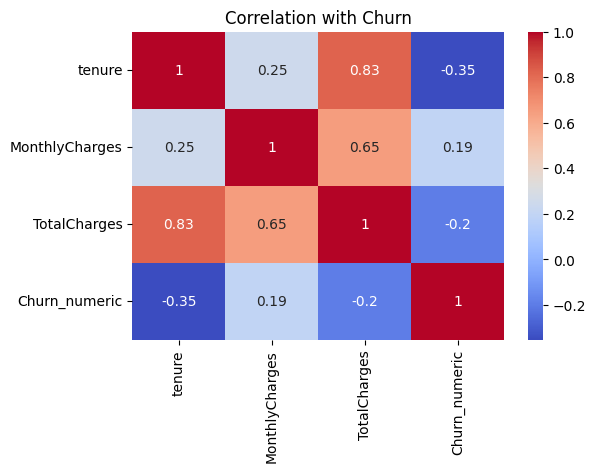

In [66]:
plt.figure(figsize=(6,4))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation with Churn')
plt.show()

## Observation

- **Tenure** has the strongest negative correlation with Churn (-0.35), meaning the longer a customer stays with the company, the lower their chance of churning.
- **TotalCharges** and **tenure** show a high correlation with each other (0.83), which is expected since longer tenure naturally leads to higher total charges.
- **MonthlyCharges** shows a weak positive correlation with Churn (0.19), meaning higher monthly bills slightly increase the likelihood of churn.

### **Scatter Plot for Linear Separability Analysis**

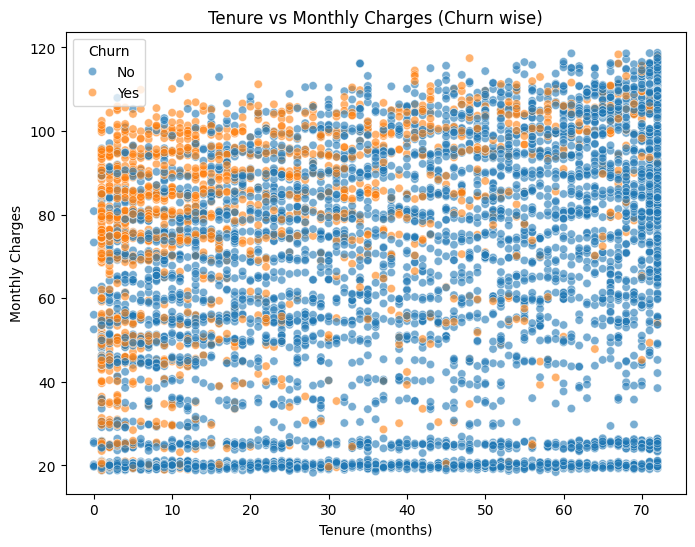

In [67]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='tenure', y='MonthlyCharges', hue='Churn', data=df, alpha=0.6)
plt.title('Tenure vs Monthly Charges (Churn wise)')
plt.xlabel('Tenure (months)')
plt.ylabel('Monthly Charges')
plt.show()

## Observation

- Churned customers cluster mostly in low tenure and high MonthlyCharges regions, but there's heavy overlap with non-churned customers, showing the data is **not linearly separable** — supporting the use of a non-linear model like Decision Tree.

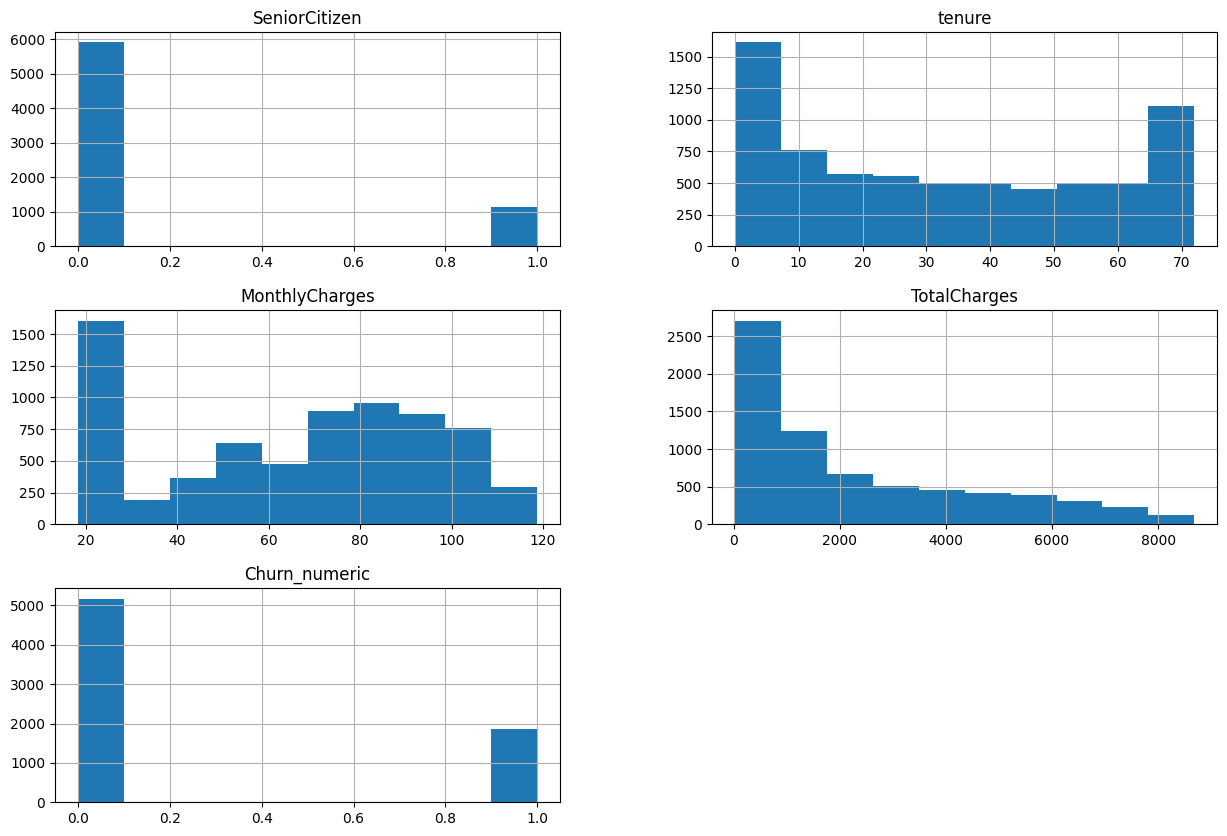

In [68]:
df.hist(figsize=(15,10))
plt.show()

## Observation

- Most binary features (gender, Partner, PhoneService, PaperlessBilling) are fairly balanced, while **SeniorCitizen** and **Churn** are highly imbalanced, with far more non-senior and non-churned customers.
- **Tenure** shows a bimodal distribution, with large groups of both new (0-10 months) and long-term (65+ months) customers.
- **MonthlyCharges** and **TotalCharges** are right-skewed, indicating most customers have lower charges with a long tail of higher-paying customers.

#### **drop extra columns**

In [69]:

df = df.drop(['customerID'], axis=1)

## **STEP 04:Encoding**

In [70]:
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

for col in binary_cols:
    df[col] = le.fit_transform(df[col])

In [71]:
multi_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
              'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
              'Contract', 'PaymentMethod']

df = pd.get_dummies(df, columns=multi_cols, drop_first=True)

In [72]:
df.head(4)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,False,False,False,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,False,False,False,False,False,True,False,False,False,True
2,1,0,0,0,2,1,1,53.85,108.15,1,...,False,False,False,False,False,False,False,False,False,True
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,True,False,False,False,False,True,False,False,False,False


In [73]:
df = df.drop(['Churn_numeric'], axis=1)

## **STEP 05:Separating Features and Target Variable**

In [74]:
X = df.drop(['Churn'], axis=1)   # sab columns except Churn
y = df['Churn']                 # sirf target column

## **SPEP 05: Train Test Split**

In [75]:


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(X_train.shape, X_test.shape)

(5634, 30) (1409, 30)


## **Decision Tree**

In [76]:
dt = DecisionTreeClassifier(
    max_depth=5,
    random_state=42,
    class_weight='balanced'
)
dt.fit(X_train,y_train)
y_predict_dt = dt.predict(X_test)

In [77]:
accuracy_score(y_test, y_predict_dt)*100

73.45635202271114

In [78]:
dt.score(X_train, y_train)*100

73.64217252396166

In [79]:
dt.score(X_test,y_test)*100

73.45635202271114

In [80]:


cv_scores = cross_val_score(dt, X, y, cv=5, scoring='accuracy')
print("Cross-Validation Scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean()*100)

Cross-Validation Scores: [0.71114265 0.74237048 0.70262598 0.73082386 0.72443182]
Mean CV Accuracy: 72.2278957513388


## **STEP 06: Model Evaluation**

### **Classification Report**

In [81]:
print(classification_report(y_test, y_predict_dt))

              precision    recall  f1-score   support

           0       0.91      0.71      0.80      1035
           1       0.50      0.81      0.62       374

    accuracy                           0.73      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.73      0.75      1409



## Observation

- Model has **improved recall for Churn (0.81)**, meaning it now correctly identifies most churners, but at the cost of **lower precision (0.50)**, resulting in more false alarms.
- Overall **accuracy dropped slightly to 0.73**, showing a trade-off where recall was prioritized over precision for better churn detection.

### **Confusion Matrix**

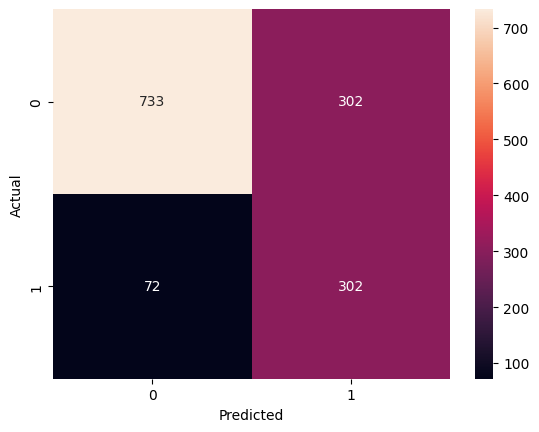

In [82]:
cm = confusion_matrix(y_test, y_predict_dt)
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## Observation

"The model correctly identifies 302 churners while missing only 72 (False Negatives), showing strong recall for the churn class. However, it also misclassifies 302 non-churners as churn (False Positives), indicating a trade-off with precision."

### **ROC_curve  and ROC_auc_score**

AUC Score: 0.831


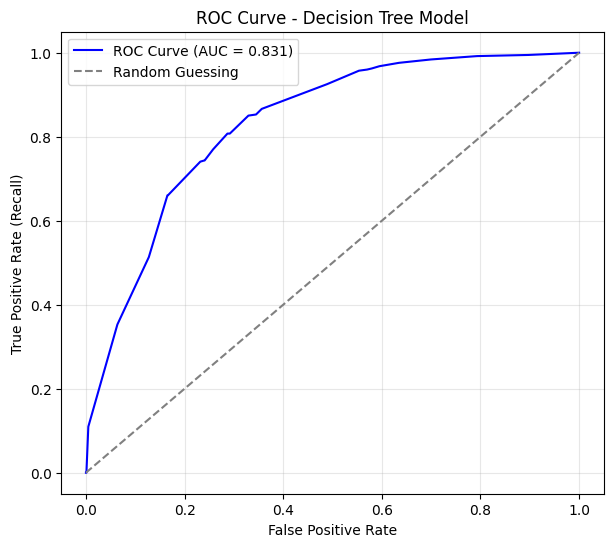

In [83]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Step 1: Model se probabilities nikalo (0.5 threshold ke bajaye raw probability)
# predict() ki jagah predict_proba() use karo
y_prob_dt = dt.predict_proba(X_test)[:, 1]   # sirf class "1" (Churn) ki probability chahiye

# Step 2: ROC curve ke points calculate karo
fpr, tpr, thresholds = roc_curve(y_test, y_prob_dt)

# Step 3: AUC score calculate karo
auc_score = roc_auc_score(y_test, y_prob_dt)
print(f"AUC Score: {auc_score:.3f}")

# Step 4: ROC curve plot karo
plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Guessing')  # diagonal line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve - Decision Tree Model')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Observation

"The model achieved an AUC score of 0.831, indicating strong overall ability to distinguish between churners and non-churners across different thresholds."

                            Feature  Importance
26                Contract_Two year    0.405269
25                Contract_One year    0.253452
11      InternetService_Fiber optic    0.111558
4                            tenure    0.094694
24              StreamingMovies_Yes    0.034102
8                      TotalCharges    0.027222
28   PaymentMethod_Electronic check    0.020621
7                    MonthlyCharges    0.019440
21  StreamingTV_No internet service    0.015233
5                      PhoneService    0.012017


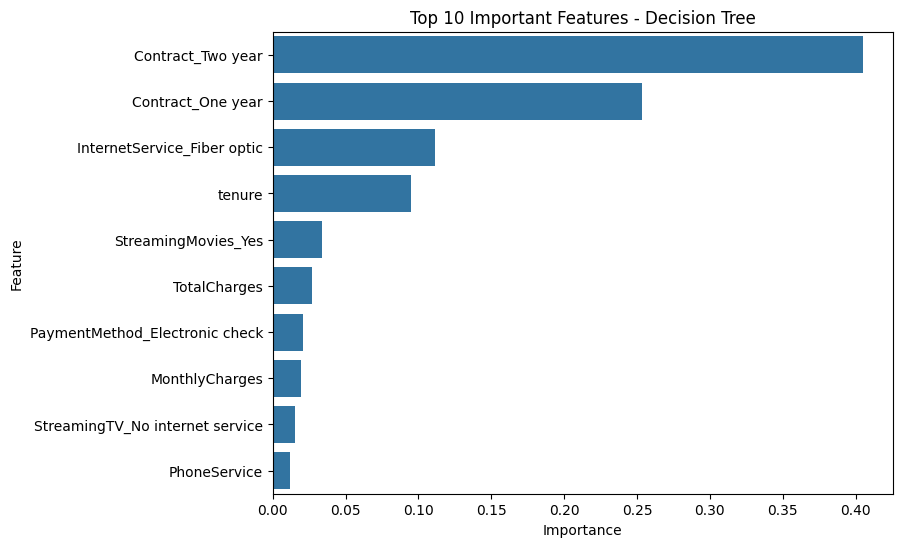

In [84]:
## STEP: Feature Importance (Decision Tree)

dt_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(dt_importance.head(10))

plt.figure(figsize=(8,6))
sns.barplot(x='Importance', y='Feature', data=dt_importance.head(10))
plt.title('Top 10 Important Features - Decision Tree')
plt.show()

## Observation

For the Decision Tree, **Contract_Two year** and **Contract_One year** dominate the importance ranking (combined ~66%), with **tenure** ranking lower (0.084) compared to its top position in Random Forest. This shows the Decision Tree relies heavily on a few strong splits (contract type), while Random Forest distributes importance more evenly across features like tenure, TotalCharges, and internet service type — a common difference between single-tree and ensemble models.

## **STEP 07: Random Forest Model Train**

In [85]:


rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42,
    class_weight='balanced'
)
rf.fit(X_train, y_train)
y_predict_rf = rf.predict(X_test)

In [86]:
accuracy_score(y_test, y_predict_rf)*100

73.66926898509581

In [87]:
rf.score(X_train, y_train)*100

75.06212282570111

In [88]:
rf.score(X_test, y_test)*100

73.66926898509581

## **STEP 08: Random Forest Evaluation**

## **Classification Report**

In [89]:
print(classification_report(y_test, y_predict_rf))

              precision    recall  f1-score   support

           0       0.91      0.71      0.80      1035
           1       0.50      0.81      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409



## **Observation**

Random Forest ~74% accuracy de raha hai. Churn class (1) ka precision kam hai (0.50) but recall theek hai (0.81) — matlab model churners ko pakar to raha hai, par false positives bhi kaafi hain. Class imbalance ka effect clearly dikh raha hai.

## **Confusion Matrix**

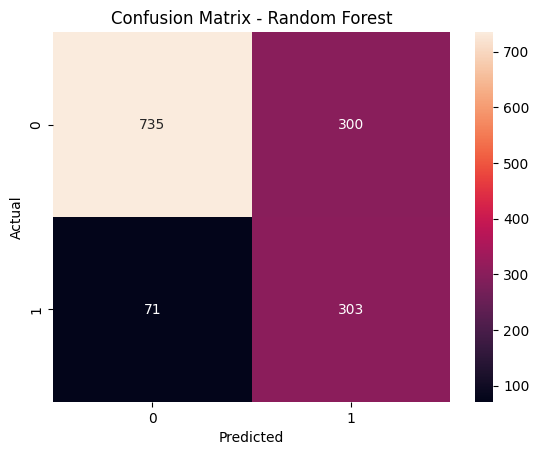

In [90]:
cm_rf= confusion_matrix(y_test, y_predict_rf)
sns.heatmap(cm_rf, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")
plt.show()

## **Observation**

Model correctly catches 303 churners while missing only 71 (good recall). However, it also flags 300 non-churners as "churn" incorrectly (high false positives), which is why precision for class 1 is low.

## **ROC Curve aur AUC**

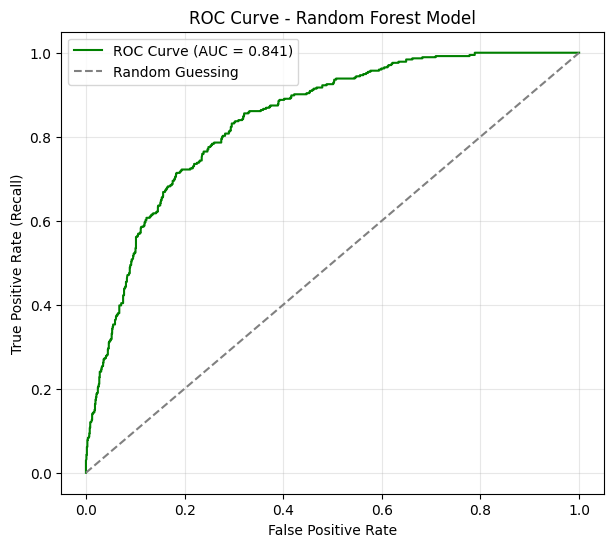

In [91]:
y_prob_rf = rf.predict_proba(X_test)[:,1]
fpr_rf, tpr_rf, thresholds_rf= roc_curve(y_test, y_prob_rf)
auc_score_rf= roc_auc_score(y_test, y_prob_rf)
plt.figure(figsize=(7,6))
plt.plot(fpr_rf, tpr_rf, color='green', label=f'ROC Curve (AUC = {auc_score_rf:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Guessing')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve - Random Forest Model')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## **Observation**

AUC score is 0.841, showing good discriminative ability of the model (distinguishing between churners and non-churners). The curve stays fairly close to the top-left corner, indicating much better performance than random guessing (dashed line).

## **STEP 9: Cross-Validation (Random Forest)**

In [92]:
cv_scores_rf = cross_val_score(rf, X, y, cv=5, scoring='accuracy')
print("Cross-Validation Scores:", cv_scores_rf)
print("Mean CV Accuracy:", cv_scores_rf.mean()*100)

Cross-Validation Scores: [0.73669269 0.75372605 0.7217885  0.72443182 0.74147727]
Mean CV Accuracy: 73.56232660171625


                                Feature  Importance
4                                tenure    0.198181
26                    Contract_Two year    0.135072
8                          TotalCharges    0.111616
11          InternetService_Fiber optic    0.095933
28       PaymentMethod_Electronic check    0.078470
25                    Contract_One year    0.044191
7                        MonthlyCharges    0.042218
13   OnlineSecurity_No internet service    0.038122
20                      TechSupport_Yes    0.031913
23  StreamingMovies_No internet service    0.029453


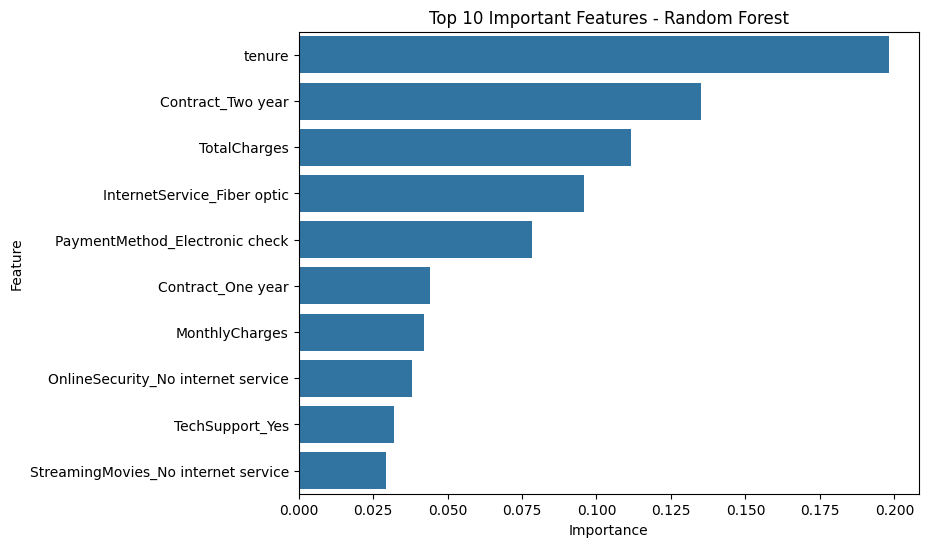

In [93]:
## STEP: Feature Importance (Random Forest)

rf_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(rf_importance.head(10))

plt.figure(figsize=(8,6))
sns.barplot(x='Importance', y='Feature', data=rf_importance.head(10))
plt.title('Top 10 Important Features - Random Forest')
plt.show()

## Observation

**Tenure** is the most important feature for the Random Forest model, followed by **Contract_Two year** and **TotalCharges**, confirming that customer loyalty duration and contract type are the strongest churn predictors. Features like **InternetService_Fiber optic** and **PaymentMethod_Electronic check** also contribute meaningfully, suggesting service type and billing method influence churn behavior.

## **Comparison Table**

In [94]:
comparison_df = pd.DataFrame({
    'Metric': ['Test Accuracy (%)', 'Mean CV Accuracy (%)', 'Precision (Churn)', 'Recall (Churn)', 'AUC Score'],
    'Decision Tree': [
        accuracy_score(y_test, y_predict_dt)*100,
        cv_scores.mean()*100,
        classification_report(y_test, y_predict_dt, output_dict=True)['1']['precision'],
        classification_report(y_test, y_predict_dt, output_dict=True)['1']['recall'],
        auc_score
    ],
    'Random Forest': [
        accuracy_score(y_test, y_predict_rf)*100,
        cv_scores_rf.mean()*100,
        classification_report(y_test, y_predict_rf, output_dict=True)['1']['precision'],
        classification_report(y_test, y_predict_rf, output_dict=True)['1']['recall'],
        auc_score_rf
    ]
})

comparison_df

,Metric,Decision Tree,Random Forest
0,Test Accuracy (%),73.456352,73.669269
1,Mean CV Accuracy (%),72.227896,73.562327
2,Precision (Churn),0.500000,0.502488
3,Recall (Churn),0.807487,0.810160
4,AUC Score,0.830754,0.841191


## **Observation**

Random Forest and Decision Tree perform almost similarly on test accuracy (~73.6%) and CV accuracy (~72-73%). Random Forest has slightly better Recall (0.81 vs 0.81) and higher AUC Score (0.841 vs 0.831), making it marginally better at ranking/distinguishing churners overall.